### Импорты и вспомогательные функции

In [2]:
import osmnx as ox
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
import pickle

from tqdm import tqdm
from collections import Counter

In [15]:
tqdm._instances.clear()

In [4]:
def save_dict_to_pickle(data, filename):
    try:
        with open(filename, 'wb') as f:
            pickle.dump(data, f)
        print(f"Данные успешно сохранены в файл: {filename}")
    except Exception as e:
        print(f"Ошибка при сохранении: {e}")

In [5]:
def run_experiment_error(G, fractions, iterations):
    # Словарь со статистикой
    stats = {f: {'S': [], '<s>': [], 'L_top': [], 'L_dist': [], 'E': [], 'C': []} for f in fractions}

    # Сделаем граф простым
    G_simple = nx.Graph(G)
    total_nodes = len(G_simple)

    for f in fractions:
        print(f"Доля удаленных узлов: {f:.2f}")
        for i in tqdm(range(iterations)):
            G_temp = G_simple.copy()

            nodes_to_remove = random.sample(list(G_temp.nodes()), int(total_nodes * f))
            G_temp.remove_nodes_from(nodes_to_remove)

            components = sorted(nx.connected_components(G_temp), key=len, reverse=True)
            components_sizes = [len(c) for c in components]

            if components_sizes:
                # Расчет S
                s_max_nodes = components[0]
                s_max_size = components_sizes[0]
                stats[f]['S'].append(s_max_size / total_nodes)

                # Расчет L
                if s_max_size > 1:
                    gcc_subgraph = G_temp.subgraph(s_max_nodes)
                    avg_top = nx.average_shortest_path_length(gcc_subgraph)
                    avg_len = nx.average_shortest_path_length(gcc_subgraph, weight='length')
                    stats[f]['L_top'].append(avg_top)
                    stats[f]['L_dist'].append(avg_len)
                else:
                    stats[f]['L_top'].append(0)
                    stats[f]['L_dist'].append(0)

                # Расчет <s>
                finite_clusters = components_sizes[1:]
                if finite_clusters:
                    sum_sq = sum(s**2 for s in finite_clusters)
                    sum_val = sum(finite_clusters)
                    stats[f]['<s>'].append(sum_sq / sum_val)
                else:
                    stats[f]['<s>'].append(0)

                # Расчет E
                ge = nx.global_efficiency(G_temp)
                stats[f]['E'].append(ge)

                # Расчет C
                lcc = nx.average_clustering(G_temp)
                stats[f]['C'].append(lcc)


            else:
                stats[f]['S'].append(0)
                stats[f]['L_top'].append(0)
                stats[f]['L_dist'].append(0)
                stats[f]['<s>'].append(0)
                stats[f]['E'].append(0)
                stats[f]['C'].append(0)
                
    return stats

In [6]:
def run_experiment_attack(G, fractions, iterations):
    # Словарь со статистикой
    stats = {f: {'S': [], '<s>': [], 'L_top': [], 'L_dist': [], 'E': [], 'C': []} for f in fractions}

    # Сделаем граф простым
    G_simple = nx.Graph(G)
    total_nodes = len(G_simple)

    for f in fractions:
        print(f"Доля удаленных узлов: {f:.2f}")
        for i in tqdm(range(iterations)):
            G_temp = G_simple.copy()

            nodes_list = list(G_simple.degree())
            random.shuffle(nodes_list)
            nodes_sorted_by_degree = [node for node, degree in sorted(nodes_list, key=lambda x: x[1], reverse=True)]

            n_to_remove = int(total_nodes * f)
            nodes_to_remove = nodes_sorted_by_degree[:n_to_remove]
            G_temp.remove_nodes_from(nodes_to_remove)

            components = sorted(nx.connected_components(G_temp), key=len, reverse=True)
            components_sizes = [len(c) for c in components]

            if components_sizes:
                # Расчет S
                s_max_nodes = components[0]
                s_max_size = components_sizes[0]
                stats[f]['S'].append(s_max_size / total_nodes)

                # Расчет L
                if s_max_size > 1:
                    gcc_subgraph = G_temp.subgraph(s_max_nodes)
                    avg_top = nx.average_shortest_path_length(gcc_subgraph)
                    avg_len = nx.average_shortest_path_length(gcc_subgraph, weight='length')
                    stats[f]['L_top'].append(avg_top)
                    stats[f]['L_dist'].append(avg_len)
                else:
                    stats[f]['L_top'].append(0)
                    stats[f]['L_dist'].append(0)

                # Расчет <s>
                finite_clusters = components_sizes[1:]
                if finite_clusters:
                    sum_sq = sum(s**2 for s in finite_clusters)
                    sum_val = sum(finite_clusters)
                    stats[f]['<s>'].append(sum_sq / sum_val)
                else:
                    stats[f]['<s>'].append(0)

                # Расчет E
                ge = nx.global_efficiency(G_temp)
                stats[f]['E'].append(ge)

                # Расчет C
                lcc = nx.average_clustering(G_temp)
                stats[f]['C'].append(lcc)


            else:
                stats[f]['S'].append(0)
                stats[f]['L_top'].append(0)
                stats[f]['L_dist'].append(0)
                stats[f]['<s>'].append(0)
                stats[f]['E'].append(0)
                stats[f]['C'].append(0)
                
    return stats

In [7]:
def plot_metrics(stats, fractions):
    metrics = ['S', '<s>', 'L_top', 'L_dist', 'E', 'C']

    fig, ax = plt.subplots(1, 6, figsize=(22, 5))

    for i, key in enumerate(metrics):
        means = [np.mean(stats[f][key]) for f in fractions]
        
        ax[i].plot(fractions, means, label=key, color='teal')
        ax[i].set_title(key.upper())
        ax[i].set_xlabel('Fraction removed')
        ax[i].grid(True, alpha=0.3)
        ax[i].set_ylim(0, None)

    plt.tight_layout() 
    plt.show()

In [8]:
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)

In [3]:
# Зададим кол-во шагов
steps = 51
# Зададим доли удаленных узлов
fractions = np.linspace(0, 1, steps)
# Зададим итерации для статистической значимости
iterations = 10

## Кольцевая структура (Москва)

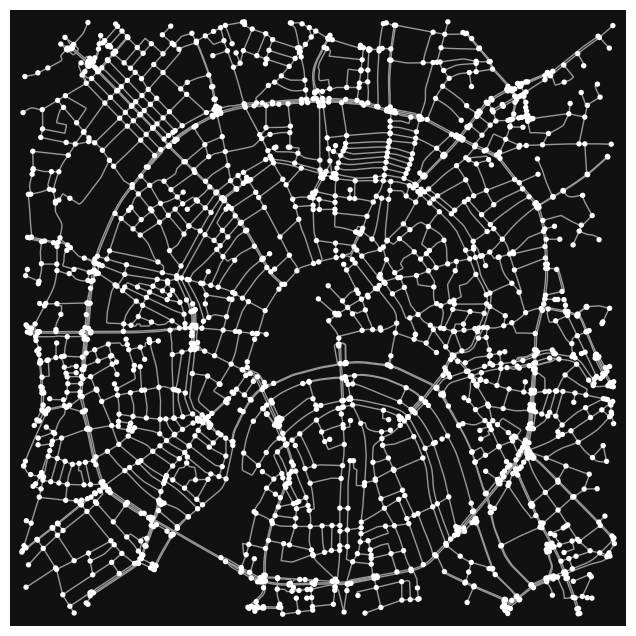

Кол-во узлов: 2066
Кол-во ребер: 3093


In [ ]:
# Координаты центра Садового кольца
center_point = (55.7539, 37.6208)

# Скачиваем граф в радиусе 3000 метров 
G_moscow = ox.graph_from_point(center_point, dist=3000, network_type='drive')

G_un = G_moscow.to_undirected()
largest_component = max(nx.connected_components(G_un), key=len)
G_moscow = G_un.subgraph(largest_component).copy()

# Визуализация
ox.plot_graph(G_moscow)

(<Figure size 800x800 with 1 Axes>, <Axes: >)

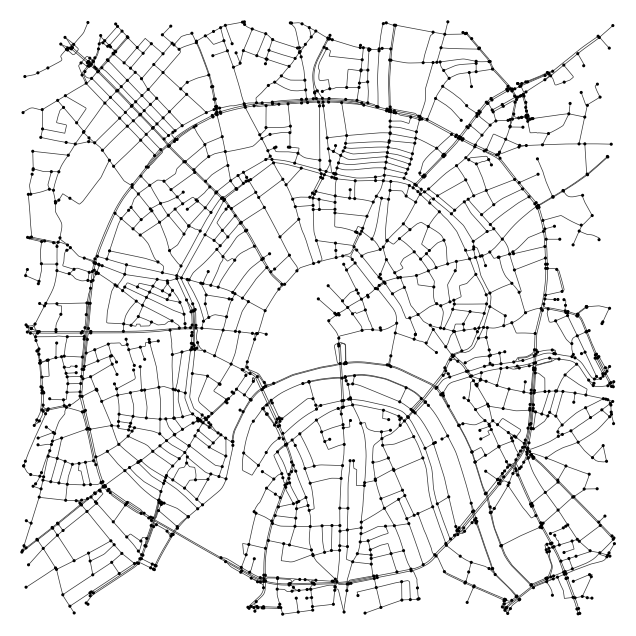

In [10]:
ox.plot_graph(
    G_moscow, 
    show=False, 
    save=True, 
    filepath='./Graphics/moscow_graph.png', 
    dpi=300,
    bgcolor='white',   
    node_color='black', 
    node_size=5,   
    edge_color='#333333', 
    edge_linewidth=0.5 
)

### Ошибки

In [ ]:
# Установим сид для воспроизводимости
set_seed(42)
# Симулируем ошибки
Moscow_error = run_experiment_error(G_moscow, fractions, iterations)

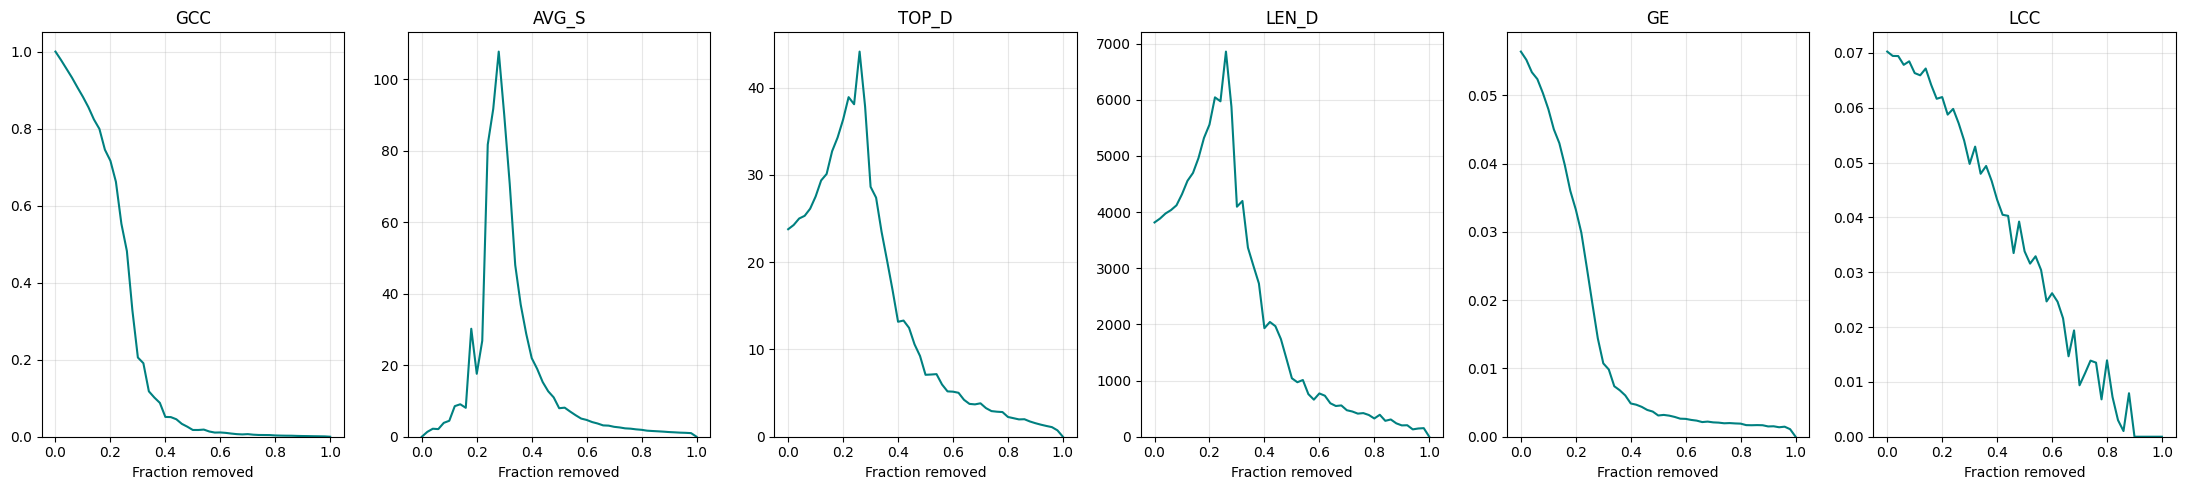

In [ ]:
# Визуализируем
plot_metrics(Moscow_error, fractions)

In [50]:
# Сохраним результат
save_dict_to_pickle(Moscow_error, "Moscow_error.pkl")

Данные успешно сохранены в файл: Moscow_error.pkl


### Атаки

In [16]:
# Установим сид для воспроизводимости
set_seed(42)
# Симулируем атаки
Moscow_attack = run_experiment_attack(G_moscow, fractions, iterations)

Доля удаленных узлов: 0.00


100%|██████████| 10/10 [06:04<00:00, 36.45s/it]


Доля удаленных узлов: 0.02


100%|██████████| 10/10 [06:18<00:00, 37.81s/it]


Доля удаленных узлов: 0.04


...

100%|██████████| 10/10 [00:00<00:00, 90.93it/s]


Доля удаленных узлов: 0.98


100%|██████████| 10/10 [00:00<00:00, 70.11it/s]


Доля удаленных узлов: 1.00


100%|██████████| 10/10 [00:00<00:00, 94.40it/s]


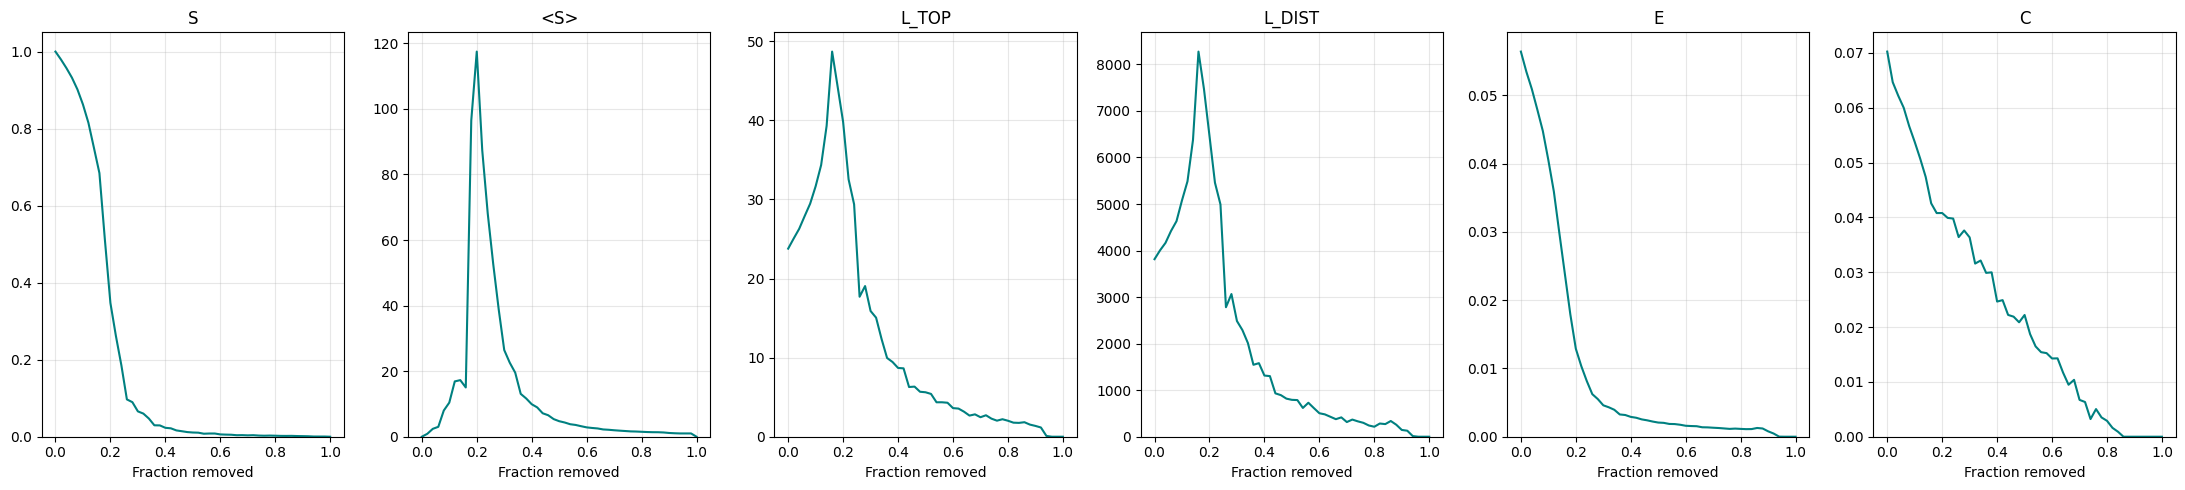

In [17]:
plot_metrics(Moscow_attack, fractions)

In [18]:
save_dict_to_pickle(Moscow_attack, "Moscow_attack.pkl")

Данные успешно сохранены в файл: Moscow_attack.pkl


## Сетчатая структура (Нью-Йорк)

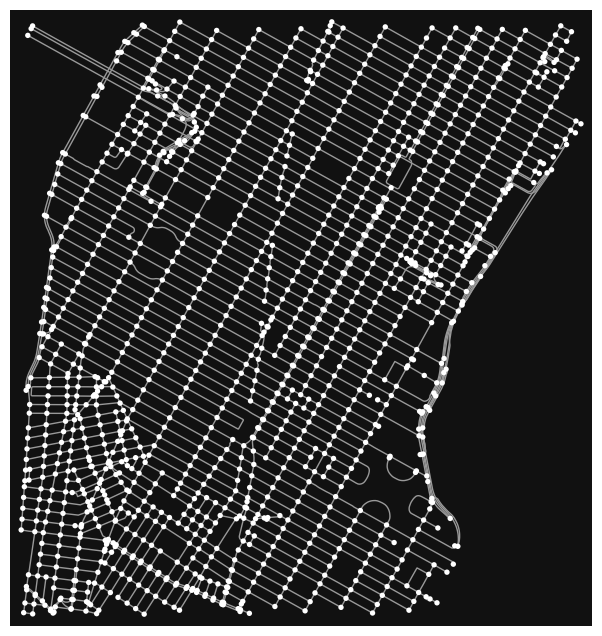

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [5]:
north = 40.7634
south = 40.7234
east = -73.9607
west = -74.0107

# Скачиваем граф строго в границах квадрата
G_nyc = ox.graph_from_bbox((west, south, east, north), network_type='drive')

G_un_ny = G_nyc.to_undirected()
largest_component_ny = max(nx.connected_components(G_un_ny), key=len)

# Создаем финальный граф
G_nyc = G_un_ny.subgraph(largest_component_ny).copy()

# Визуализация
ox.plot_graph(G_nyc)

(<Figure size 800x800 with 1 Axes>, <Axes: >)

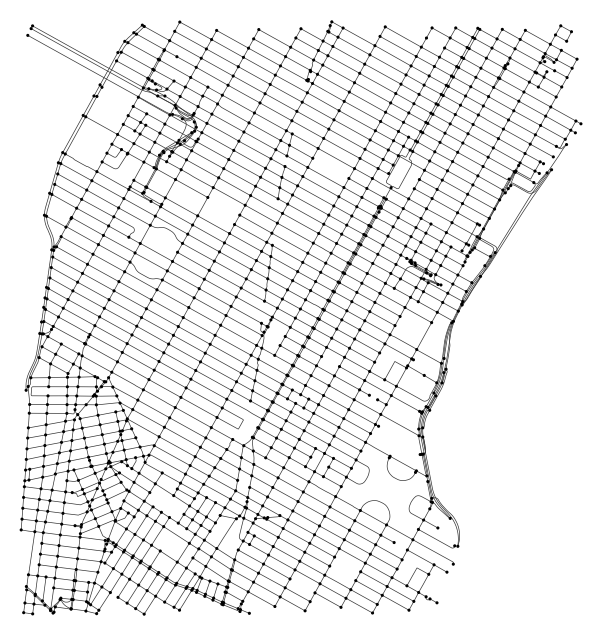

In [11]:
ox.plot_graph(
    G_nyc, 
    show=False, 
    save=True, 
    filepath='./Graphics/new_york_graph.png', 
    dpi=300,
    bgcolor='white',   
    node_color='black', 
    node_size=5,   
    edge_color='#333333', 
    edge_linewidth=0.5 
)

### Ошибки

In [12]:
# Установим сид для воспроизводимости
set_seed(42)
# Симулируем ошибки
New_York_error = run_experiment_error(G_nyc, fractions, iterations)

Доля удаленных узлов: 0.00


100%|██████████| 10/10 [02:44<00:00, 16.42s/it]


Доля удаленных узлов: 0.02


100%|██████████| 10/10 [02:39<00:00, 15.99s/it]


Доля удаленных узлов: 0.04


...

100%|██████████| 10/10 [00:00<00:00, 136.74it/s]


Доля удаленных узлов: 0.98


100%|██████████| 10/10 [00:00<00:00, 146.07it/s]


Доля удаленных узлов: 1.00


100%|██████████| 10/10 [00:00<00:00, 100.83it/s]


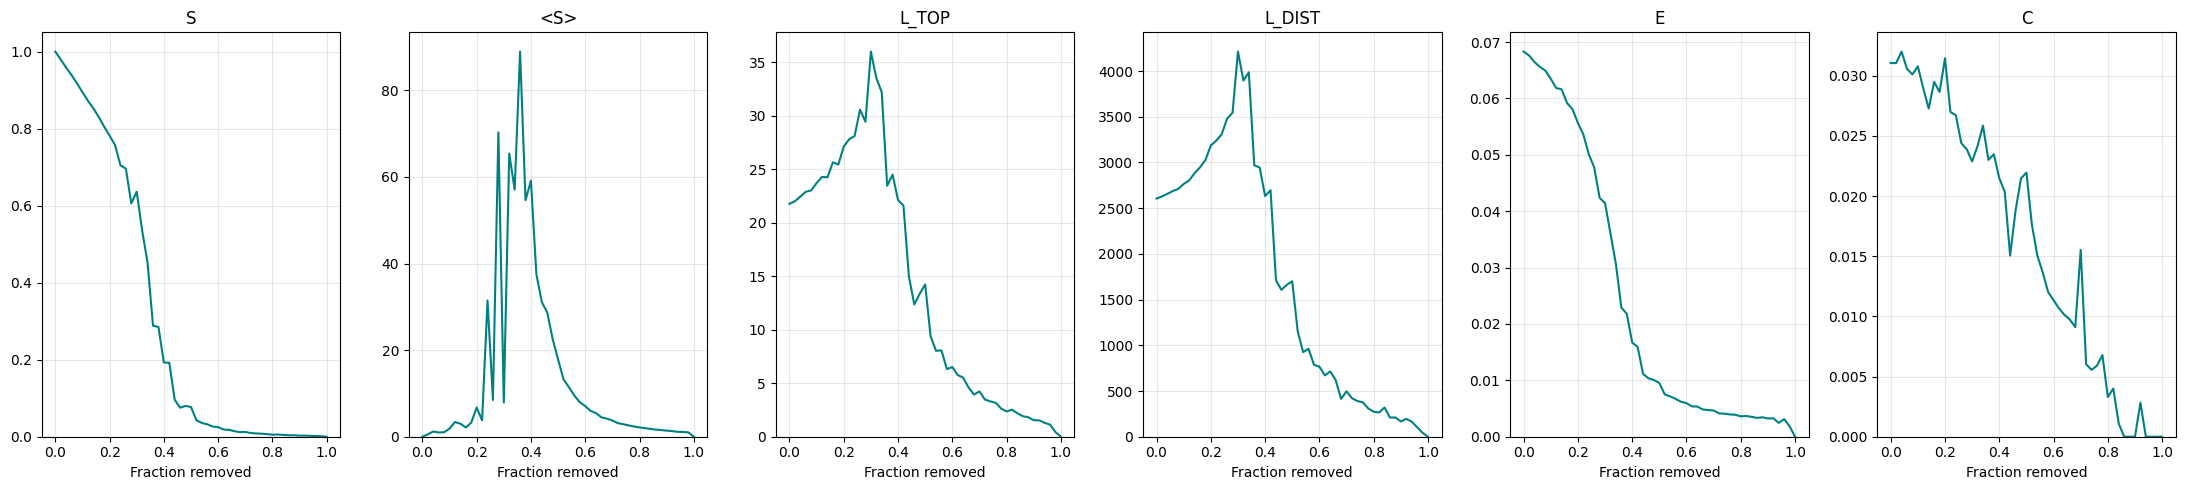

In [14]:
plot_metrics(New_York_error, fractions)

In [16]:
save_dict_to_pickle(New_York_error, "New_York_error.pkl")

Данные успешно сохранены в файл: New_York_error.pkl


### Атаки

In [17]:
# Установим сид для воспроизводимости
set_seed(42)
# Симулируем атаки
New_York_attack = run_experiment_attack(G_nyc, fractions, iterations)

Доля удаленных узлов: 0.00


100%|██████████| 10/10 [02:36<00:00, 15.63s/it]


Доля удаленных узлов: 0.02


100%|██████████| 10/10 [02:14<00:00, 13.41s/it]


Доля удаленных узлов: 0.04


...

100%|██████████| 10/10 [00:00<00:00, 129.80it/s]


Доля удаленных узлов: 0.98


100%|██████████| 10/10 [00:00<00:00, 102.10it/s]


Доля удаленных узлов: 1.00


100%|██████████| 10/10 [00:00<00:00, 132.27it/s]


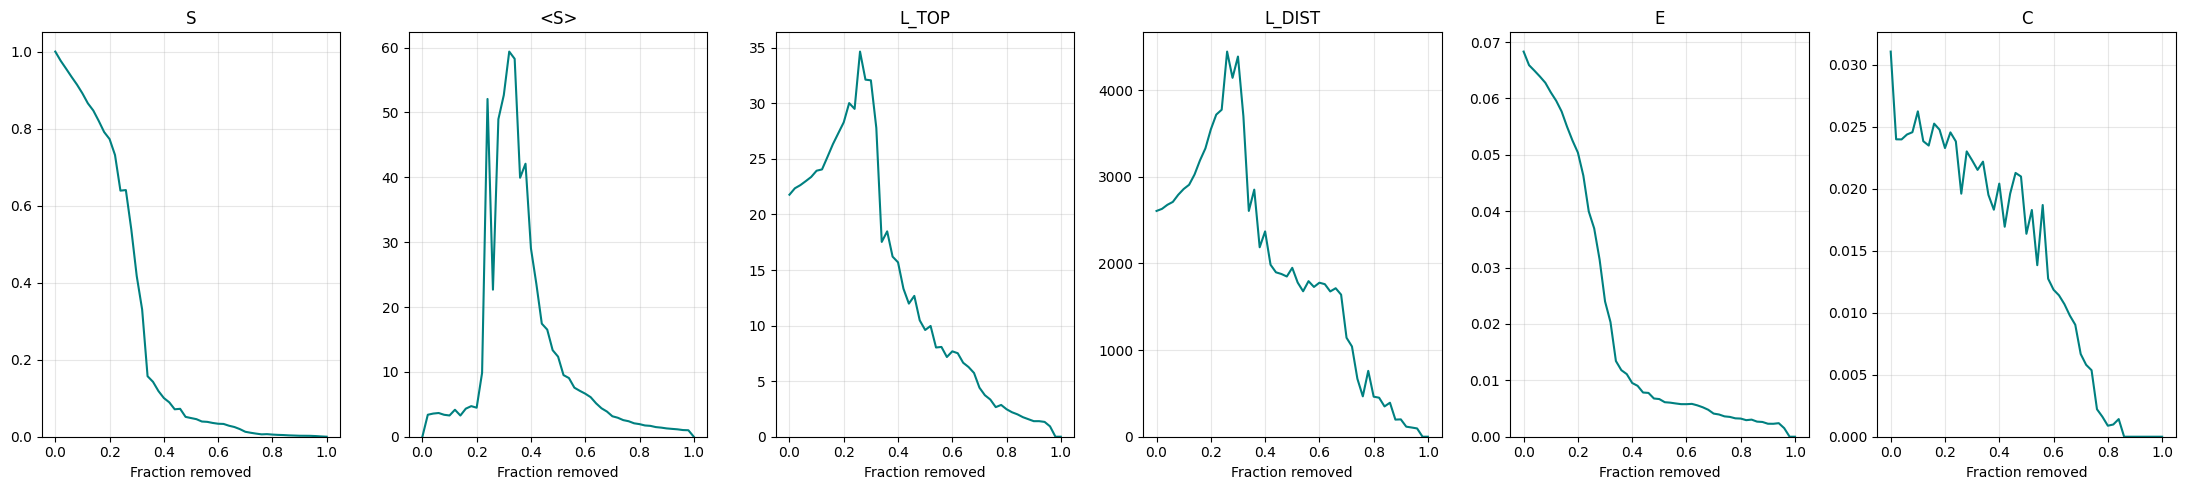

In [18]:
plot_metrics(New_York_attack, fractions)

In [19]:
save_dict_to_pickle(New_York_attack, "New_York_attack.pkl")

Данные успешно сохранены в файл: New_York_attack.pkl


## Линейная структура (Волгоград)

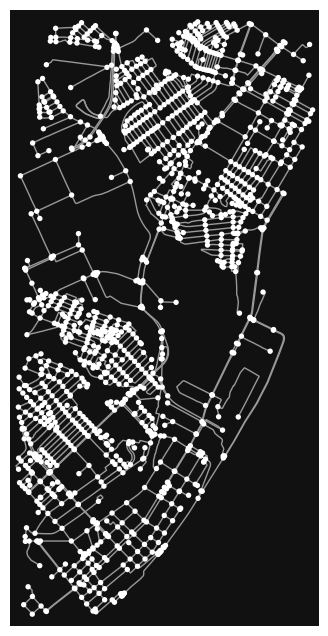

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [6]:
# Пример получения линейного участка Волгограда
north, south = 48.78, 48.70 
east, west = 44.56, 44.50
G_volgograd = ox.graph_from_bbox((west, south, east, north), network_type='drive')

G_un_vol = G_volgograd.to_undirected()
largest_component_vol = max(nx.connected_components(G_un_vol), key=len)

G_volgograd = G_un_vol.subgraph(largest_component_vol).copy()

# Визуализация
ox.plot_graph(G_volgograd)

(<Figure size 800x800 with 1 Axes>, <Axes: >)

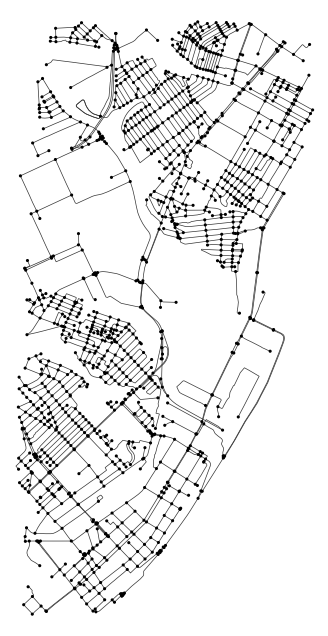

In [12]:
ox.plot_graph(
    G_volgograd, 
    show=False, 
    save=True, 
    filepath='./Graphics/volgograd_graph.png', 
    dpi=300,
    bgcolor='white',   
    node_color='black', 
    node_size=5,   
    edge_color='#333333', 
    edge_linewidth=0.5 
)

### Ошибки

In [ ]:
# Установим сид для воспроизводимости
set_seed(42)
# Симулируем ошибки
Volgograd_error = run_experiment_error(G_volgograd, fractions, iterations)

Доля удаленных узлов: 0.00


100%|██████████| 10/10 [02:38<00:00, 15.89s/it]


Доля удаленных узлов: 0.02


100%|██████████| 10/10 [02:27<00:00, 14.78s/it]


Доля удаленных узлов: 0.04


...

100%|██████████| 10/10 [00:00<00:00, 99.95it/s]


Доля удаленных узлов: 0.98


100%|██████████| 10/10 [00:00<00:00, 73.58it/s]


Доля удаленных узлов: 1.00


100%|██████████| 10/10 [00:00<00:00, 130.60it/s]


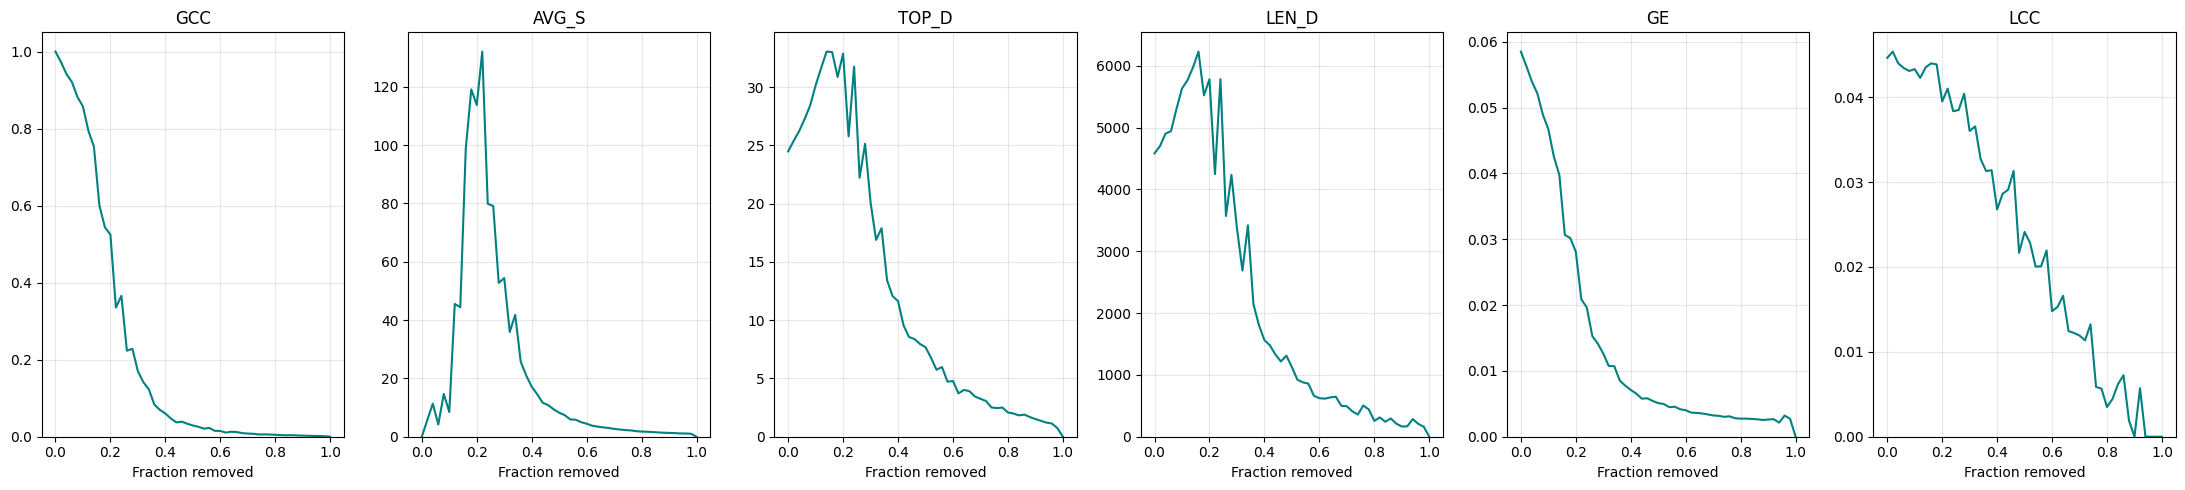

In [88]:
plot_metrics(Volgograd_error, fractions)

In [89]:
save_dict_to_pickle(Volgograd_error, "Volgograd_error.pkl")

Данные успешно сохранены в файл: Volgograd_error.pkl


### Атаки

In [25]:
# Установим сид для возпроизводимости
set_seed(42)
# Симулируем атаки
Volgograd_attack = run_experiment_attack(G_volgograd, fractions, iterations)

Доля удаленных узлов: 0.00


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [02:29<00:00, 14.92s/it]


Доля удаленных узлов: 0.02


100%|██████████| 10/10 [02:27<00:00, 14.78s/it]


...

100%|██████████| 10/10 [00:00<00:00, 127.91it/s]


Доля удаленных узлов: 0.98


100%|██████████| 10/10 [00:00<00:00, 126.16it/s]


Доля удаленных узлов: 1.00


100%|██████████| 10/10 [00:00<00:00, 131.16it/s]


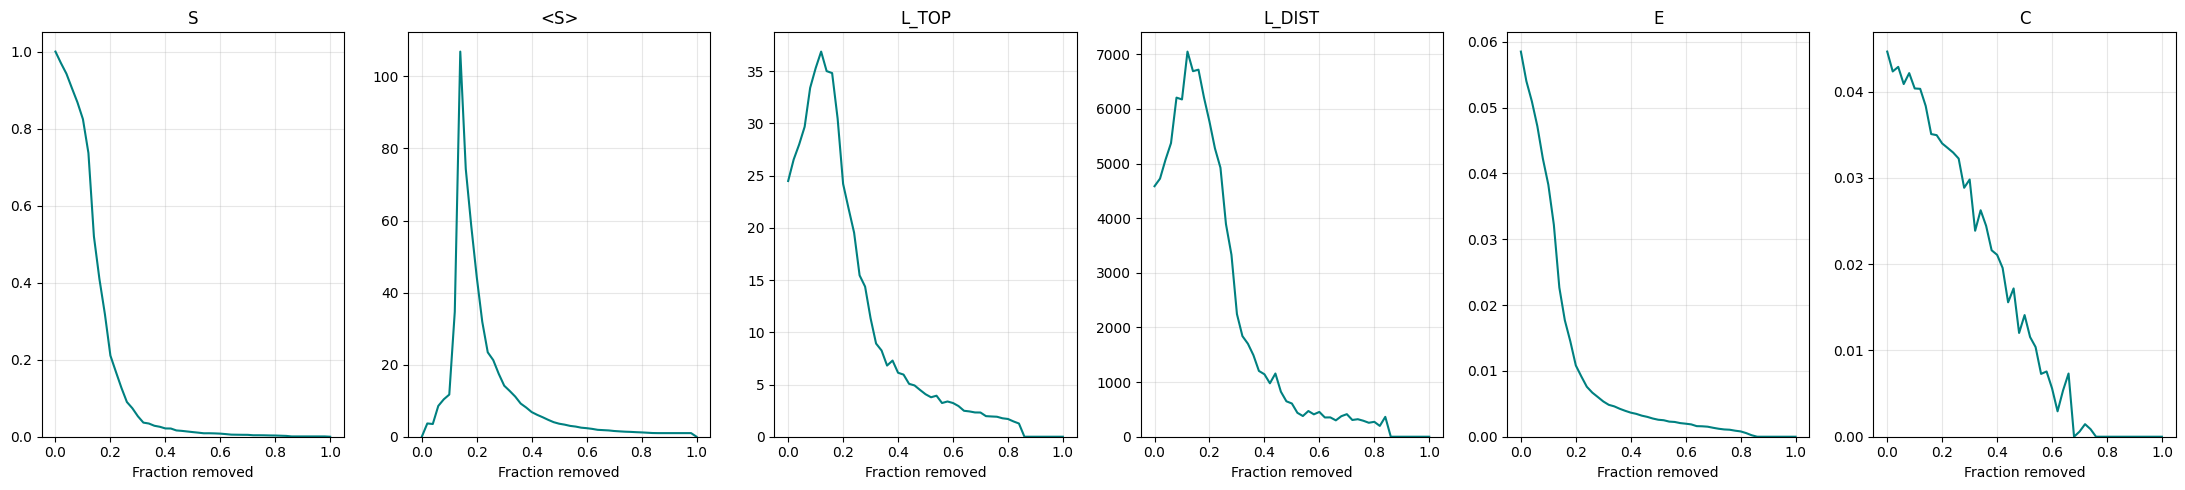

In [26]:
plot_metrics(Volgograd_attack, fractions)

In [27]:
save_dict_to_pickle(Volgograd_attack, "Volgograd_attack.pkl")

Данные успешно сохранены в файл: Volgograd_attack.pkl


## Органическая структура (Лондон)

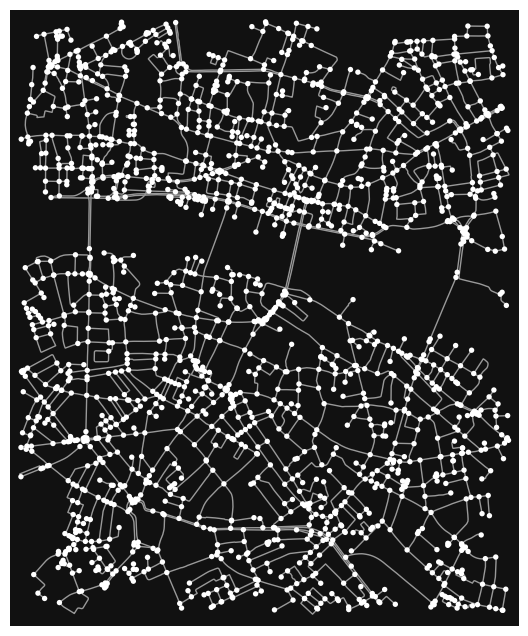

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [7]:
# Исторический центр Лондона 
west, south, east, north = -0.11, 51.49, -0.07, 51.52

G_london = ox.graph_from_bbox((west, south, east, north), network_type='drive')

G_un_lon = G_london.to_undirected()
largest_component_lon = max(nx.connected_components(G_un_lon), key=len)

# Создаем финальный граф 
G_london = G_un_lon.subgraph(largest_component_lon).copy()

# Визуализация 
ox.plot_graph(G_london)

(<Figure size 800x800 with 1 Axes>, <Axes: >)

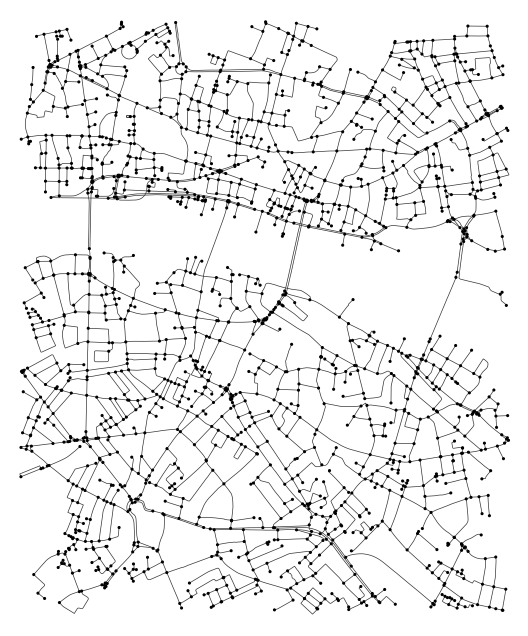

In [13]:
ox.plot_graph(
    G_london, 
    show=False, 
    save=True, 
    filepath='./Graphics/london_graph.png', 
    dpi=300,
    bgcolor='white',   
    node_color='black', 
    node_size=5,   
    edge_color='#333333', 
    edge_linewidth=0.5 
)

### Ошибки

In [ ]:
# Установим сид для возпроизводимости
set_seed(42)
# Симулируем ошибки
London_error = run_experiment_error(G_london, fractions, iterations)

Доля удаленных узлов: 0.00


100%|██████████| 10/10 [07:56<00:00, 47.66s/it]


Доля удаленных узлов: 0.02


100%|██████████| 10/10 [06:00<00:00, 36.03s/it]


Доля удаленных узлов: 0.04


...

100%|██████████| 10/10 [00:00<00:00, 91.65it/s]


Доля удаленных узлов: 0.98


100%|██████████| 10/10 [00:00<00:00, 84.58it/s]


Доля удаленных узлов: 1.00


100%|██████████| 10/10 [00:00<00:00, 60.87it/s]


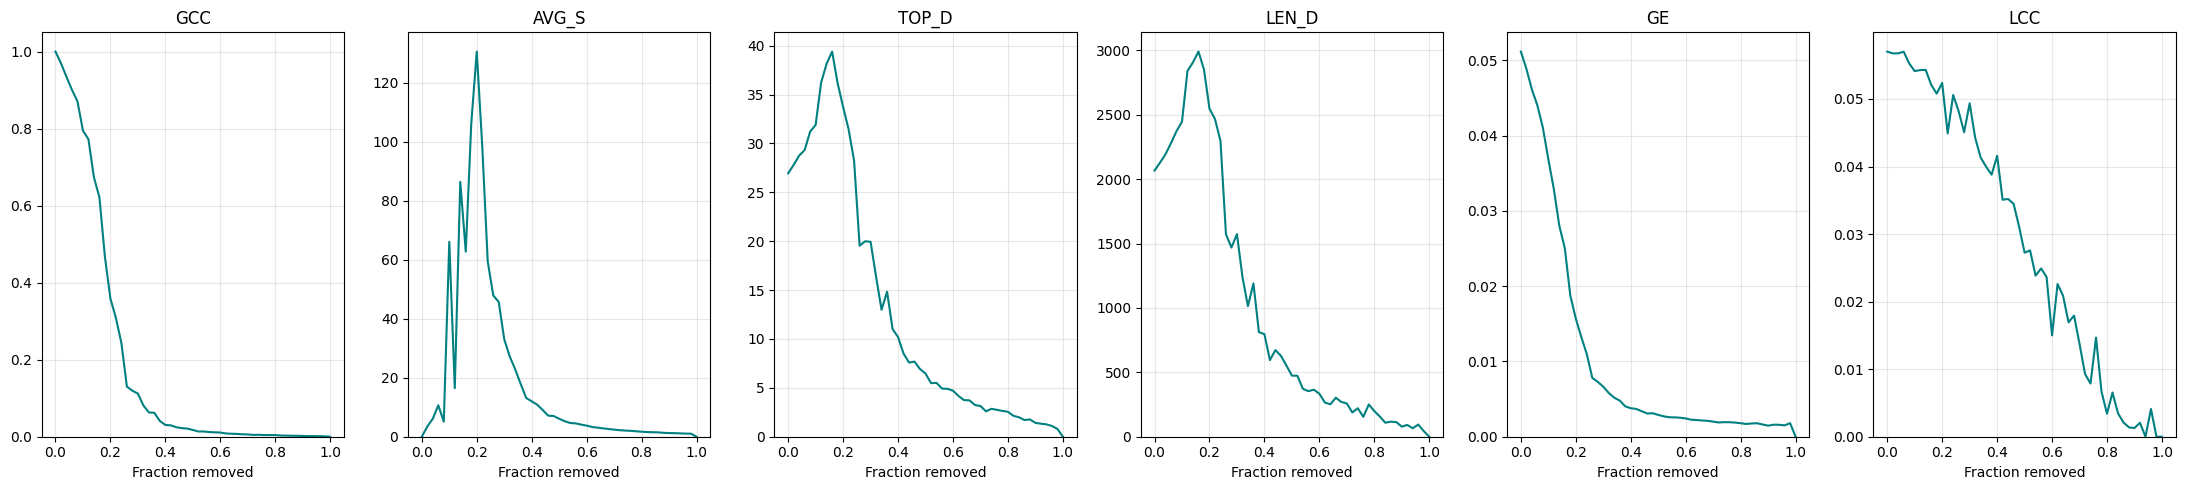

In [97]:
plot_metrics(London_error, fractions)

In [98]:
save_dict_to_pickle(London_error, "London_error.pkl")

Данные успешно сохранены в файл: London_error.pkl


### Атаки

In [29]:
# Установим сид для возпроизводимости
set_seed(42)
# Симулируем атаки
London_attack = run_experiment_attack(G_london, fractions, iterations)

Доля удаленных узлов: 0.00


100%|██████████| 10/10 [04:55<00:00, 29.54s/it]


Доля удаленных узлов: 0.02


100%|██████████| 10/10 [04:31<00:00, 27.15s/it]


Доля удаленных узлов: 0.04


...

100%|██████████| 10/10 [00:00<00:00, 75.13it/s]


Доля удаленных узлов: 0.98


100%|██████████| 10/10 [00:00<00:00, 59.06it/s]


Доля удаленных узлов: 1.00


100%|██████████| 10/10 [00:00<00:00, 82.25it/s]


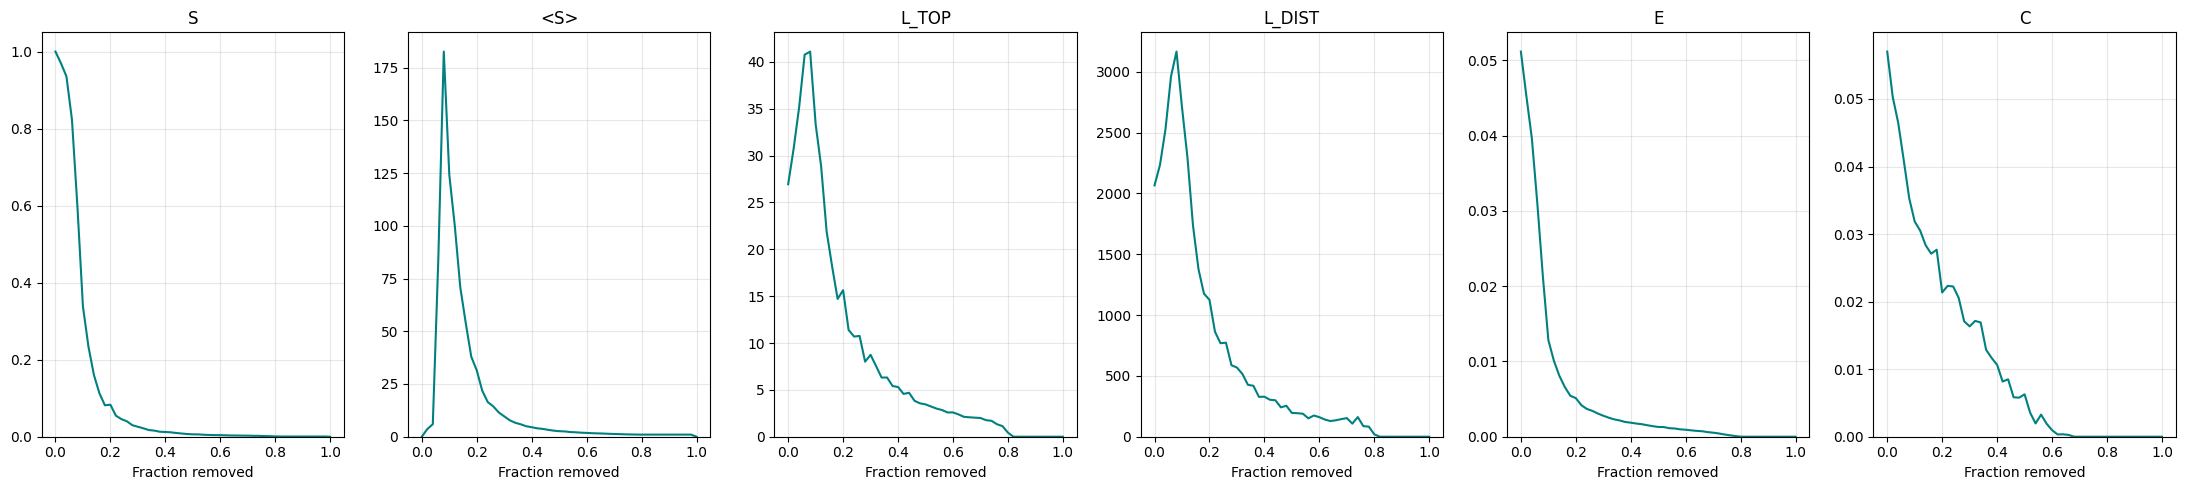

In [30]:
plot_metrics(London_attack, fractions)

In [31]:
save_dict_to_pickle(London_attack, "London_attack.pkl")

Данные успешно сохранены в файл: London_attack.pkl


## Статистики графов

Москва
Узлы: 2066
Ребра: 3093
Средняя степень узла: 2.99

Нью-Йорк
Узлы: 1314
Ребра: 2345
Средняя степень узла: 3.57

Волгоград
Узлы: 1310
Ребра: 1907
Средняя степень узла: 2.91

Лондон
Узлы: 1806
Ребра: 2360
Средняя степень узла: 2.61



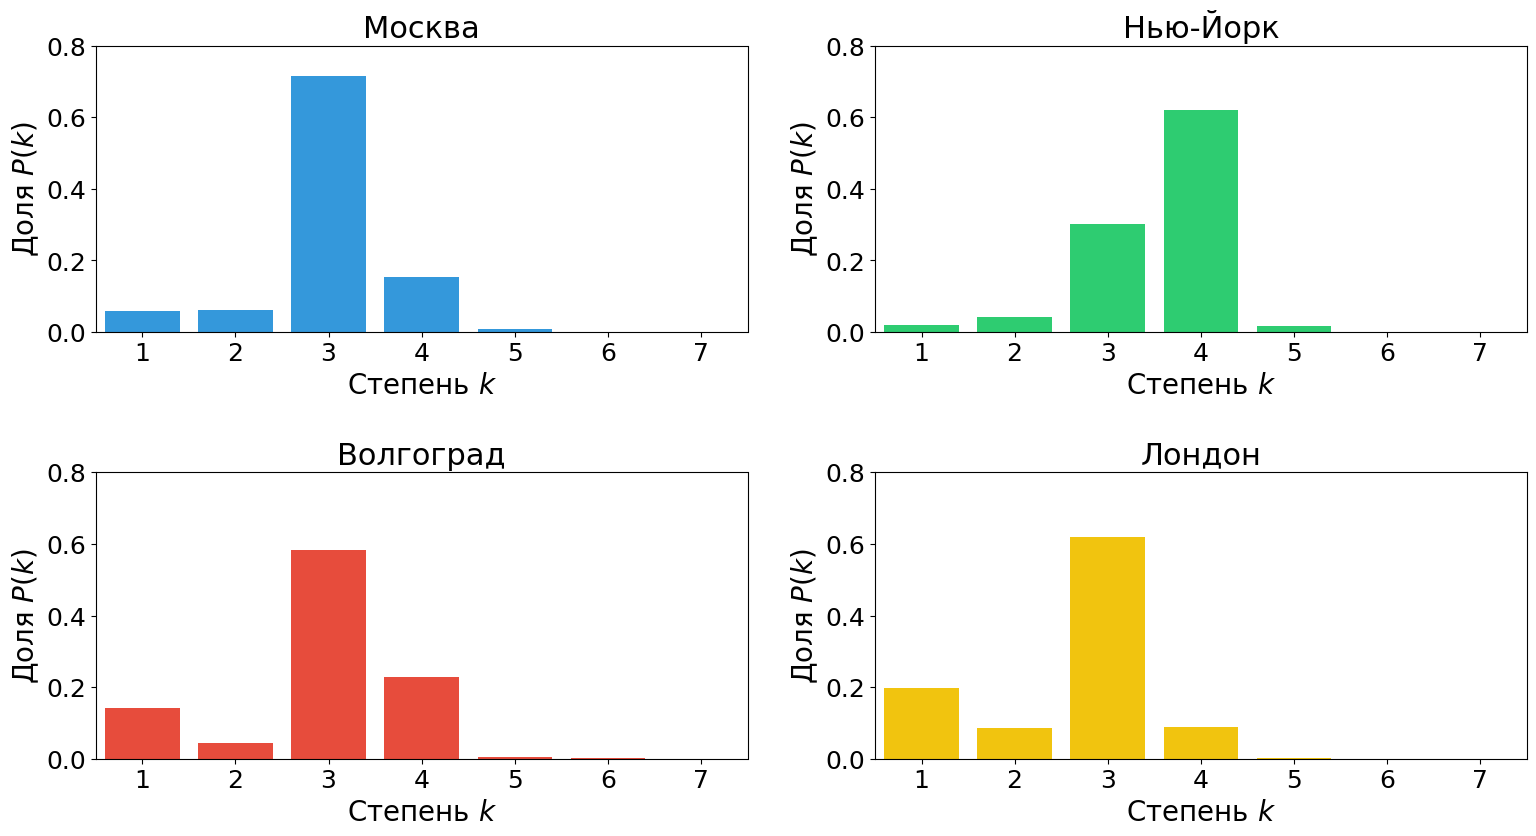

In [14]:
cities = [G_moscow, G_nyc, G_volgograd, G_london]
names = ["Москва", "Нью-Йорк", "Волгоград", "Лондон"]

styles = [{'color': '#3498db'}, {'color': '#2ecc71'}, {'color': '#e74c3c'}, {'color': '#f1c40f'}]
       

fig, ax = plt.subplots(2, 2, figsize = (16, 9))

for i, city in enumerate(cities):
    n_nodes = city.number_of_nodes()
    n_edges = city.number_of_edges()
    avg_degree = round(sum(dict(city.degree()).values()) / n_nodes, 2)
    density = round(nx.density(city))
    degrees = [d for _, d in city.degree()]

    print(f"{names[i]}")
    print(f"Узлы: {n_nodes}")
    print(f"Ребра: {n_edges}")
    print(f"Средняя степень узла: {avg_degree}")
    print()

    degree_counts = Counter(degrees)
    total = sum(degree_counts.values())

    x = sorted(degree_counts.keys())
    y = [degree_counts[k] / total for k in x]

    ax[i//2, i%2].bar(x, y, **styles[i])
    ax[i//2, i%2].set_xlabel("Степень $k$", fontsize=20)
    ax[i//2, i%2].set_ylabel("Доля $P(k)$", fontsize=20)
    ax[i//2, i%2].set_title(f"{names[i]}", fontsize=22)
    ax[i//2, i%2].set_xlim(0.5, 7.5)
    ax[i//2, i%2].set_ylim(0, 0.8)
    ax[i//2, i%2].tick_params(labelsize=18)

plt.tight_layout(pad=3)
plt.savefig(
    './Deg_dist.png', 
    dpi=300,           
    bbox_inches='tight', 
    pad_inches=0.1,      
    transparent=False,   
    facecolor='white'
)

plt.show()
